In [ ]:
''' 
임의의 3차원 특성 벡터를 가정하자. 
이 벡터는 1개의 큰 클러스터(샘플 100개)와 또다른 1개의 작은 클러스터(샘플 30)를 형성하고 있다. 
그리고 나머지 10개의 이상치는 이 두개의 클러스터와 거리를 두고 흩어져 있다. 
이와 같은 특성 벡터 샘플을 이용하여 정상치와 이상치를 구분하는 LOF를 구현하는 파이썬 코드를 작성해줘.
'''

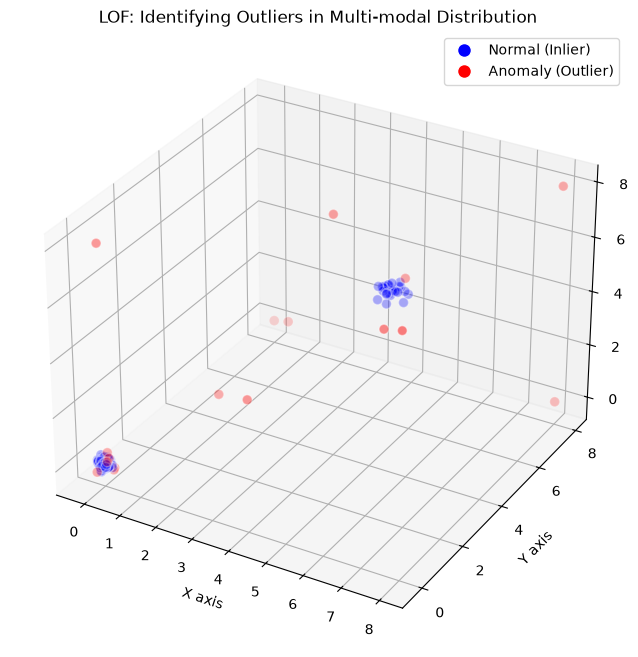

전체 샘플 수: 140
탐지된 정상 샘플 (Inliers): 121
탐지된 이상치 (Outliers): 19


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from mpl_toolkits.mplot3d import Axes3D  # 3D 시각화를 위한 라이브러리
from matplotlib.lines import Line2D

# 1. 데이터 생성 (Data Generation)
np.random.seed(42)

# [Case 1] 큰 클러스터 (Large Cluster) - 100개 샘플
# 중심이 (0,0,0)이고 아주 촘촘한 분포
large_cluster = np.random.normal(loc=[0, 0, 0], scale=0.1, size=(100, 3))

# [Case 2] 작은 클러스터 (Small Cluster) - 30개 샘플
# 중심이 (5,5,5)이고 큰 클러스터보다는 약간 퍼져 있지만, 여전히 뭉쳐 있음
small_cluster = np.random.normal(loc=[5, 5, 5], scale=0.2, size=(30, 3))

# [Case 3] 이상치 (Outliers) - 10개 샘플
# 두 클러스터 사이의 빈 공간이나 아주 먼 곳에 흩어져 있음
outliers = np.array([
    [2, 2, 2], [8, 8, 8], [1, 7, 1], [7, 1, 7], [4, 0, 4],
    [0, 8, 0], [8, 0, 8], [0, 0, 8], [8, 8, 0], [4, 4, 8]
])

# 모든 데이터 합치기
X = np.vstack([large_cluster, small_cluster, outliers])

# 2. LOF 모델 적용 (Local Outlier Factor)
# n_neighbors는 주변 이웃 몇 개를 볼 것인가를 결정합니다.
lof = LocalOutlierFactor(n_neighbors=10)
y_pred = lof.fit_predict(X)  # 1은 정상(Inlier), -1은 이상치(Outlier)

# LOF 점수 추출 (값이 클수록 이상치)
lof_scores = -lof.negative_outlier_factor_

# 3. 시각화 (Visualization)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 색상 지정
# 1 (정상) -> 파란색, -1 (이상치) -> 빨간색
colors = []
for label in y_pred:
    if label == 1:
        colors.append('blue')  # 대규모 클러스터/소규모 클러스터용
    else:
        colors.append('red')   # 이상치

# 데이터 산점도 그리기
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=colors, s=50, edgecolors='w', alpha=0.7)

# 축 라벨 설정
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('LOF: Identifying Outliers in Multi-modal Distribution')

# 범례(Legend)를 위한 가상 포인트
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Normal (Inlier)', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Anomaly (Outlier)', markerfacecolor='red', markersize=10)
]
ax.legend(handles=legend_elements)

plt.show()

# 4. 결과 분석 출력
n_inliers = list(y_pred).count(1)
n_outliers = list(y_pred).count(-1)
print(f"전체 샘플 수: {len(X)}")
print(f"탐지된 정상 샘플 (Inliers): {n_inliers}")
print(f"탐지된 이상치 (Outliers): {n_outliers}")

In [ ]:
''' 
모든 점의 LOF 점수를 점수 상단에 표시하도록 코드를 수정해줘. 만일 점이 너무 많이 모여있다면 대표 점수(평균) 하나만 출력하도록 해줘.
'''

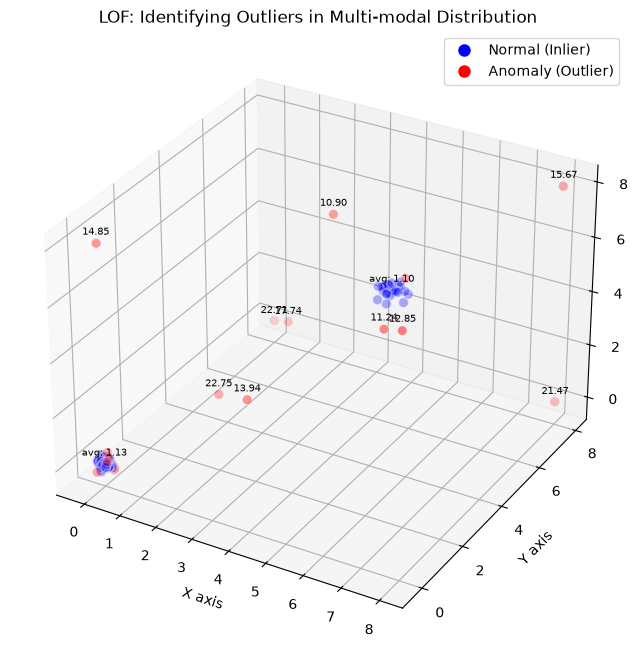

전체 샘플 수: 140
탐지된 정상 샘플 (Inliers): 121
탐지된 이상치 (Outliers): 19


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from mpl_toolkits.mplot3d import Axes3D  # 3D 시각화를 위한 라이브러리
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import linkage, fcluster

# 1. 데이터 생성 (Data Generation)
np.random.seed(42)

# [Case 1] 큰 클러스터 (Large Cluster) - 100개 샘플
large_cluster = np.random.normal(loc=[0, 0, 0], scale=0.1, size=(100, 3))

# [Case 2] 작은 클러스터 (Small Cluster) - 30개 샘플
small_cluster = np.random.normal(loc=[5, 5, 5], scale=0.2, size=(30, 3))

# [Case 3] 이상치 (Outliers) - 10개 샘플
outliers = np.array([
    [2, 2, 2], [8, 8, 8], [1, 7, 1], [7, 1, 7], [4, 0, 4],
    [0, 8, 0], [8, 0, 8], [0, 0, 8], [8, 8, 0], [4, 4, 8]
])

# 모든 데이터 합치기
X = np.vstack([large_cluster, small_cluster, outliers])

# 2. LOF 모델 적용 (Local Outlier Factor)
lof = LocalOutlierFactor(n_neighbors=10)
y_pred = lof.fit_predict(X)  # 1은 정상(Inlier), -1은 이상치(Outlier)

# LOF 점수 추출 (값이 클수록 이상치)
lof_scores = -lof.negative_outlier_factor_

# 3. 밀집도 기반 그룹핑 (라벨 표시용)
# 서로 가까운 점들을 하나의 그룹으로 묶어서, 그룹 크기가 크면 평균 점수 하나만 표시
DIST_THRESHOLD = 0.8   # 이 거리 이내에 있는 점들은 같은 그룹으로 취급 (데이터 스케일에 맞게 조정)
MIN_GROUP_SIZE_FOR_AVG = 5  # 그룹 내 점 개수가 이 값 이상이면 대표(평균) 점수만 표시

Z = linkage(X, method='single')
group_ids = fcluster(Z, t=DIST_THRESHOLD, criterion='distance')

label_positions = []  # (x, y, z, score_text)
for gid in np.unique(group_ids):
    idx = np.where(group_ids == gid)[0]
    if len(idx) >= MIN_GROUP_SIZE_FOR_AVG:
        # 점이 많이 모여있는 그룹 -> 중심점에 평균 점수 하나만 표시
        centroid = X[idx].mean(axis=0)
        avg_score = lof_scores[idx].mean()
        label_positions.append((*centroid, f"avg: {avg_score:.2f}"))
    else:
        # 점이 적은(흩어진) 그룹 -> 각 점 위에 개별 점수 표시
        for i in idx:
            label_positions.append((*X[i], f"{lof_scores[i]:.2f}"))

# 4. 시각화 (Visualization)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 색상 지정
colors = []
for label in y_pred:
    if label == 1:
        colors.append('blue')
    else:
        colors.append('red')

# 데이터 산점도 그리기
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=colors, s=50, edgecolors='w', alpha=0.7)

# 점수 라벨을 점 상단에 표시
Z_OFFSET = 0.3  # 점 위쪽으로 살짝 띄워서 표시
for x, y, z, text in label_positions:
    ax.text(x, y, z + Z_OFFSET, text, fontsize=7, ha='center', color='black')

# 축 라벨 설정
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('LOF: Identifying Outliers in Multi-modal Distribution')

# 범례(Legend)를 위한 가상 포인트
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Normal (Inlier)', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Anomaly (Outlier)', markerfacecolor='red', markersize=10)
]
ax.legend(handles=legend_elements)

plt.show()

# 5. 결과 분석 출력
n_inliers = list(y_pred).count(1)
n_outliers = list(y_pred).count(-1)
print(f"전체 샘플 수: {len(X)}")
print(f"탐지된 정상 샘플 (Inliers): {n_inliers}")
print(f"탐지된 이상치 (Outliers): {n_outliers}")

In [8]:
# 논문의 의도와 다르다 : 새로 생성 (260803)
'''
임의의 3차원 특성 벡터를 가정하자. 
이 벡터는 1개의 큰 클러스터(샘플 100개)와 또다른 1개의 작은 클러스터(샘플 30)를 형성하고 있다. 
그리고 나머지 10개는 이 두개의 클러스터와 거리를 두고 흩어져 있다. 
이와 같은 특성 벡터 샘플을 이용하여 정상치와 이상치를 구분하는 LOF를 구현하는 파이썬 코드를 작성해줘.'''

'\n임의의 3차원 특성 벡터를 가정하자. \n이 벡터는 1개의 큰 클러스터(샘플 100개)와 또다른 1개의 작은 클러스터(샘플 30)를 형성하고 있다. \n그리고 나머지 10개는 이 두개의 클러스터와 거리를 두고 흩어져 있다. \n이와 같은 특성 벡터 샘플을 이용하여 정상치와 이상치를 구분하는 LOF를 구현하는 파이썬 코드를 작성해줘.'

전체 샘플 수: 140 (큰 클러스터 100 / 작은 클러스터 30 / 흩어진 점 10)
직접 구현한 LOF vs sklearn LOF 점수 상관계수: 1.0000  (1.0에 가까울수록 구현이 정확함)

threshold τ=0.15 적용 → 상위 21개 패치를 이상치로 판별
판별된 이상치의 실제 소속 집단 분포:
  - big_cluster: 8개
  - scattered: 10개
  - small_cluster: 3개

시각화 결과 저장: /mnt/user-data/outputs/lof_result.png


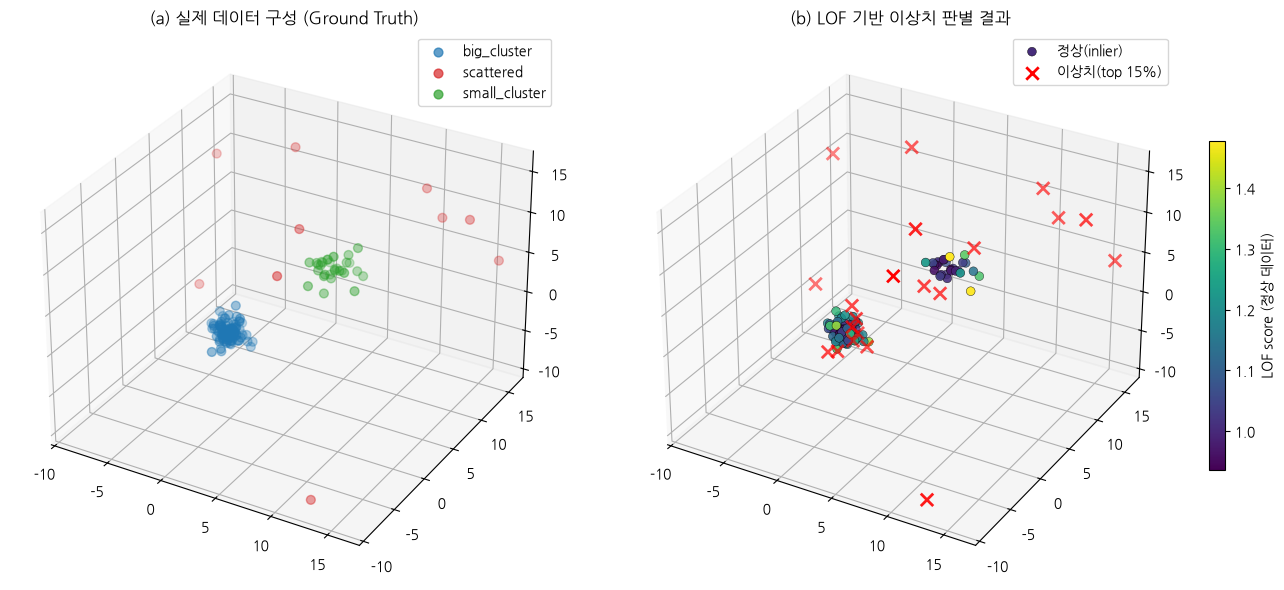

In [ ]:
"""
LOF(Local Outlier Factor)를 이용한 정상치/이상치 판별 예제
- SoftPatch 논문 3.2.3절의 수식 (4), (5), (6)을 그대로 구현
- 데이터 구성: 큰 클러스터(100개) + 작은 클러스터(30개) + 흩어진 이상치(10개)
- sklearn의 LocalOutlierFactor와 결과를 비교하여 구현이 올바른지 검증
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
for font_path in fm.findSystemFonts():
    if "Nanum" in font_path:
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (3D 프로젝션 등록)
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

# ----------------------------------------------------------------------
# 1. 3차원 특성 벡터 샘플 생성
#    - 큰 클러스터: 100개, 중심 (0, 0, 0) 근처, 밀도 높음(표준편차 작음)
#    - 작은 클러스터: 30개, 중심 (6, 6, 6) 근처, 밀도 낮음(표준편차 조금 큼)
#    - 흩어진 이상치: 10개, 두 클러스터에서 멀리 떨어진 무작위 위치
# ----------------------------------------------------------------------
n_big, n_small, n_outlier = 100, 30, 10

big_cluster = np.random.normal(loc=[0, 0, 0], scale=0.8, size=(n_big, 3))
small_cluster = np.random.normal(loc=[6, 6, 6], scale=1.2, size=(n_small, 3))

# 두 클러스터와 거리를 두고 무작위로 흩어진 점들
outliers = np.random.uniform(low=-10, high=16, size=(n_outlier, 3))
# 혹시 클러스터 근처에 우연히 생성되면 밀어내기(간단한 후처리)
for i in range(n_outlier):
    while (np.linalg.norm(outliers[i] - [0, 0, 0]) < 4 or
           np.linalg.norm(outliers[i] - [6, 6, 6]) < 4):
        outliers[i] = np.random.uniform(low=-10, high=16, size=3)

X = np.vstack([big_cluster, small_cluster, outliers])
labels_true = np.array(
    ["big_cluster"] * n_big + ["small_cluster"] * n_small + ["scattered"] * n_outlier
)

print(f"전체 샘플 수: {X.shape[0]} (큰 클러스터 {n_big} / 작은 클러스터 {n_small} / 흩어진 점 {n_outlier})")


# ----------------------------------------------------------------------
# 2. LOF를 논문 수식(4)~(6) 그대로 구현
#    W_LOF_i = ( sum_{b in Nk(i)} lrd_b ) / ( |Nk(i)| * lrd_i )
#    -> 값이 1에 가까우면 정상(이웃과 밀도가 비슷함)
#       값이 클수록 이상치(자신의 밀도가 이웃보다 훨씬 낮음)
# ----------------------------------------------------------------------
def compute_lof(X, k=6):
    n = X.shape[0]

    # k+1개를 구하는 이유: 첫 번째 이웃은 자기 자신이므로 제외하기 위함
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
    distances, indices = nn.kneighbors(X)
    distances = distances[:, 1:]   # 자기 자신(거리 0) 제외
    indices = indices[:, 1:]

    # k-distance: k번째 이웃까지의 거리 (수식 5의 dist_k)
    k_distance = distances[:, -1]

    # reachability distance (수식 5)
    # dist_reach_k(i, b) = max(dist_k(b), d(i, b))
    reach_dist = np.zeros((n, k))
    for i in range(n):
        for j, b in enumerate(indices[i]):
            reach_dist[i, j] = max(k_distance[b], distances[i, j])

    # local reachability density (수식 4)
    lrd = 1.0 / (reach_dist.mean(axis=1) + 1e-12)

    # 상대 밀도 = LOF 점수 (수식 6)
    lof_score = np.zeros(n)
    for i in range(n):
        neighbor_lrd = lrd[indices[i]]
        lof_score[i] = neighbor_lrd.mean() / (lrd[i] + 1e-12)

    return lof_score, lrd, k_distance


k = 6  # 논문에서 사용한 기본값(LOF-K = 6)
lof_score_manual, lrd_manual, kdist_manual = compute_lof(X, k=k)


# ----------------------------------------------------------------------
# 3. sklearn의 LocalOutlierFactor로 검증
#    (sklearn은 negative_outlier_factor_ = -LOF 를 반환하므로 부호를 뒤집어 비교)
# ----------------------------------------------------------------------
sk_lof = LocalOutlierFactor(n_neighbors=k)
sk_lof.fit_predict(X)
lof_score_sklearn = -sk_lof.negative_outlier_factor_

corr = np.corrcoef(lof_score_manual, lof_score_sklearn)[0, 1]
print(f"직접 구현한 LOF vs sklearn LOF 점수 상관계수: {corr:.4f}  (1.0에 가까울수록 구현이 정확함)")


# ----------------------------------------------------------------------
# 4. 이상치 판별 (논문의 threshold tau 방식: 상위 tau% 를 이상치로 간주)
# ----------------------------------------------------------------------
tau = 0.15  # 논문 기본값 15%
n_remove = int(np.ceil(len(X) * tau))
threshold_idx = np.argsort(lof_score_manual)[::-1][:n_remove]

is_outlier = np.zeros(len(X), dtype=bool)
is_outlier[threshold_idx] = True

print(f"\nthreshold τ={tau} 적용 → 상위 {n_remove}개 패치를 이상치로 판별")
print("판별된 이상치의 실제 소속 집단 분포:")
unique, counts = np.unique(labels_true[is_outlier], return_counts=True)
for u, c in zip(unique, counts):
    print(f"  - {u}: {c}개")


# ----------------------------------------------------------------------
# 5. 3D 시각화 : 정상(파랑) vs 이상치(빨강) + LOF 점수 크기로 표현
# ----------------------------------------------------------------------
fig = plt.figure(figsize=(14, 6))

# (a) 실제 소속 클러스터 기준 (Ground Truth)
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
colors = {"big_cluster": "tab:blue", "small_cluster": "tab:green", "scattered": "tab:red"}
for label in np.unique(labels_true):
    mask = labels_true == label
    ax1.scatter(X[mask, 0], X[mask, 1], X[mask, 2],
                c=colors[label], label=label, s=40, alpha=0.7)
ax1.set_title("(a) 실제 데이터 구성 (Ground Truth)")
ax1.legend()

# (b) LOF 계산 결과 기준 (정상 vs 이상치)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
sc = ax2.scatter(X[~is_outlier, 0], X[~is_outlier, 1], X[~is_outlier, 2],
                  c=lof_score_manual[~is_outlier], cmap="viridis", s=40,
                  edgecolors="black", linewidths=0.3,
                  label="정상(inlier)",
                  vmin=lof_score_manual[~is_outlier].min(),
                  vmax=lof_score_manual[~is_outlier].max())
ax2.scatter(X[is_outlier, 0], X[is_outlier, 1], X[is_outlier, 2],
            c="red", marker="x", s=80, linewidths=2, label=f"이상치(top {tau*100:.0f}%)")
ax2.set_title("(b) LOF 기반 이상치 판별 결과")
ax2.legend()
fig.colorbar(sc, ax=ax2, shrink=0.6, label="LOF score (정상 데이터)")

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/lof_result.png", dpi=150)
print("\n시각화 결과 저장: /mnt/user-data/outputs/lof_result.png")